In [99]:
from pathlib import Path
import sys

%load_ext autoreload
%reload_ext autoreload
%autoreload 2

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "NeuralNetwork" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import itertools


from src.data_utils import (
    load_data,
    df_to_tensors,
    signed_log1p,
    log_output,
    scale_input,
    oversample_high_values,
    split_tensors,
    get_kfold_splits,
    create_dataloaders,
)
from src.engine import set_seed, find_lr, train_model, cross_validate_model
from src.model import build_model
from src.testing import evaluate_regression, observed_predicted
from src.visualization import plot_predicted_vs_observed
from src.logger import log_run
from tqdm.autonotebook import tqdm

set_seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [101]:
# OVERSAMPLE_THRESHOLD = 
# OVERSAMPLE_FACTOR = 

BATCH_SIZE = 64
LR = 1e-3

In [102]:
data = load_data(str(ROOT / "data" / "features.csv"))
TARGET_COL = 'dens'

x_raw, y_raw = df_to_tensors(data, TARGET_COL)

X_train, y_train, X_test, y_test = split_tensors(x_raw, y_raw, test_size=0.2, seed=42)

X_train = signed_log1p(X_train)
X_test = signed_log1p(X_test)

# X_train, y_train = oversample_high_values(
#         X_train, y_train,
#         threshold=OVERSAMPLE_THRESHOLD,
#         repeat_factor=OVERSAMPLE_FACTOR
# )

X_train_scaled, X_test_scaled, _ = scale_input(X_train, X_test)

y_train_log = log_output(y_train)
y_test_log   = log_output(y_test)

train_loader = create_dataloaders(X_train_scaled, y_train_log, batch_size=BATCH_SIZE, shuffle=False)
test_loader   = create_dataloaders(X_test_scaled, y_test_log, batch_size=BATCH_SIZE)

In [103]:
# loss_func = nn.MSELoss()

loss_func=nn.HuberLoss(delta=1.0)

model = build_model()

model.train()

model, _ = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    epochs=150,
    lr=LR,
    loss_func=loss_func,
    patience=20,
    verbose=True
)

Epoch 10/150 | Train Loss: 0.0628 | Val Loss: 0.0332
Epoch 20/150 | Train Loss: 0.0537 | Val Loss: 0.0301
Epoch 30/150 | Train Loss: 0.0499 | Val Loss: 0.0298
Epoch 40/150 | Train Loss: 0.0467 | Val Loss: 0.0291
Epoch 50/150 | Train Loss: 0.0446 | Val Loss: 0.0286
Epoch 60/150 | Train Loss: 0.0414 | Val Loss: 0.0291
Epoch 70/150 | Train Loss: 0.0384 | Val Loss: 0.0279
Epoch 80/150 | Train Loss: 0.0358 | Val Loss: 0.0281
Epoch 90/150 | Train Loss: 0.0347 | Val Loss: 0.0277
Epoch 100/150 | Train Loss: 0.0338 | Val Loss: 0.0273
Epoch 110/150 | Train Loss: 0.0338 | Val Loss: 0.0275
Epoch 120/150 | Train Loss: 0.0314 | Val Loss: 0.0269
Epoch 130/150 | Train Loss: 0.0318 | Val Loss: 0.0269
Epoch 140/150 | Train Loss: 0.0303 | Val Loss: 0.0268
Epoch 150/150 | Train Loss: 0.0309 | Val Loss: 0.0266


NEURAL NETWORK
RMSE    : 32.0606
MAE     : 6.3761
%RMSE   : 153.90%
R^2     : 0.7852


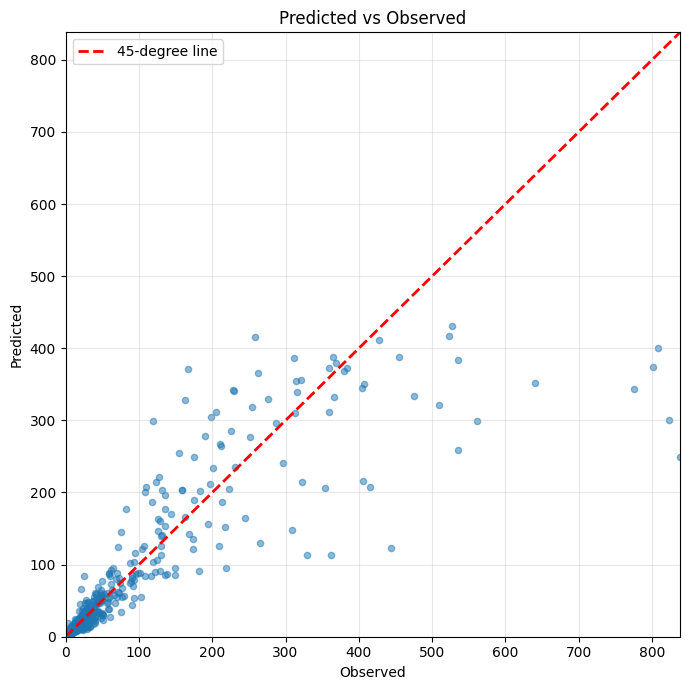

In [107]:
observed, predicted = observed_predicted(model, test_loader, device)
print("NEURAL NETWORK")
evaluate_regression(observed, predicted)
plot_predicted_vs_observed(observed, predicted)
